# General notebook preparation: Libaries and Datasets

At the beginning, the basic libaries that we work with need to be imported. That includes pandas for data read out, matplot libary for basic plotting, numpy for numeric operations, seaborn for advanced plotting and scipy stats for statistical calculations.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
from pathlib import Path

Here, our cleaned-up and filtered ATAC-seq dataset is imported.

In [5]:
ATAC_path_pfiltered = Path('data') / 'ATAC_pfiltered.csv'
ATAC_pfiltered = pd.read_csv(ATAC_path_pfiltered)
ATAC_seq = ATAC_pfiltered.copy()

ATACseq_reg = ATAC_seq[ATAC_seq["TSS"].isnull()]


This dataset is a subunit of ATAC_pfiltered, but only with the Tgd-cells cells.

In [6]:
ATAC_path_Tgd = Path('data') / 'ATAC_seq_gd_anot.csv'
ATAC_Tgd = pd.read_csv(ATAC_path_Tgd)
ATAC_seq_gd = ATAC_Tgd.copy()

Finally, the cleaned-up RNA-seq dataset is read out. For further analysis, a RNA-seq dataset including only the Tgd-cells is also created.

In [17]:
RNA_seq = pd.read_csv('data/mmc2.csv')
RNA_seq = RNA_seq.set_index("Unnamed: 0")  # Gennamen als Index setzen

Tgd_cells = [
    "MPP4.135+.BM",
    "preT.DN1.Th",
    "preT.DN2a.Th",
    "preT.DN2b.Th",
    "preT.DN3.Th",
    "T.DN4.Th",
    "Tgd.g1.1+d1.24a+.Th",
    "Tgd.g2+d1.24a+.Th",
    "Tgd.g2+d17.24a+.Th",
    "Tgd.Sp",
    "Tgd.g1.1+d1.LN",
    "Tgd.g2+d1.LN",
    "Tgd.g2+d17.LN"
]

RNA_Tgd = RNA_seq[Tgd_cells].copy()
RNA_seq_gd = RNA_Tgd.copy()


In [8]:
meta_cols = ["TSS", "genes.within.100Kb", "_-log10_bestPvalue", "Included.in.systematic.analysis",
             "ImmGenATAC1219.peakID", "chrom", "Summit", "mm10.60way.phastCons_scores"]
signal_cols_all = [col for col in ATAC_pfiltered.columns 
                   if col not in meta_cols 
                   and col in RNA_seq.columns] #alle Zelltypen Spaltennamen in ATAC, 
#ohne meta_cols und nur, wenn in ATAC, aber als liste und
signal_cols_all

signal_cols_tgd = Tgd_cells 

# CRE–Gene Association via Regression

## How much variance in gene expression can a regression model explain per gene

### Theory and Implementation

<h3> Ridge Regression and Cross Validation </h3>

In the linear regression model, parameters are estimated using the least-squares method to minimize the sum of squared residuals. However, strong correlation between features leads to overly large coefficients. Thus, the linear regression model was too unreliable due to excessive collinearity among the peaks.

**Ridge Regression** is applied, which introduces a penalty for excessively large coefficients to increase model stability.

$$\min_{w} \vert{}\vert{}Xw - y\vert{}\vert{}^2_2 + \alpha \vert{}\vert{}w\vert{}\vert{}^2_2$$

* **Least squares part:** $$\vert{}\vert{}Xw - y\vert{}\vert{}^2_2$$ 
* **Penalty part ($\alpha$):** $$\alpha \vert{}\vert{}w\vert{}\vert{}^2_2$$

**Cross-validation** was used for control:
1. The dataset is split into $K$ blocks of equal size.
2. The model is then trained and tested 5 times.
3. In each round, a different block is used as test data, while the remaining four blocks serve as training data.

<h3> Python Implementation</h3>

* One model is trained across all cell types.
* One model is trained specific to γδ T-cells.

<h5> Workflow</h5>

1. **Genes are selected**
   * γδ T-cells specific genes (from section 2.2: Genes with a high Gini coefficient from the γδ T-cell specific lineage).
2. **ATAC data is filtered:** Peaks within 100Kb of the selected gene's region are extracted.
3. **A matrix is built and Ridge Regression is applied.**

### Function of the regression model (R^2): all cell types

**Function R^2_gen**

1. A matrix is created: X = peaks, Y = gene expression
2. Ridge Regression is run to select the best alpha
3. Cross Validation with best alpha
4. Predicted values are plotted against actual values
5. A residual plot is created

In [23]:
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold

annotation_cols = ["ImmGenATAC1219.peakID", "chrom", "Summit",
                   "mm10.60way.phastCons_scores", "_-log10_bestPvalue",
                   "Included.in.systematic.analysis", "TSS", "genes.within.100Kb"]


def r2_gen(gen_name, plot=True, plot_residues=True): 
    
    #Y: Gen-Expression
    RNA_seq_gen = RNA_seq.loc[[gen_name]]  #Gen Namen von Unnamed in gen_name speichern
    y = RNA_seq_gen.T  #Unnamed zeile entfernen und Matrix transponiernen (Zelltypen sind Zeilen)

    # ATAC Datensatz Filtern, sodass nur peaks gewählt werden die mit Gen assoziert sind, also within 100kb
    ATAC_seq_gen = ATAC_seq[ATAC_seq["genes.within.100Kb"].fillna("").str.contains(rf"\b{gen_name}\b")]

    peak_ids = ATAC_seq_gen["ImmGenATAC1219.peakID"].values  # ← vor .T
    X = ATAC_seq_gen.drop(annotation_cols, axis=1, errors="ignore").T #ATAC datenstz transformieren: Spalten = Peaks


    #nur gemeinsame Zellen behalten behalten
    cells = X.index.intersection(y.index)
    X = X.loc[cells]
    y = y.loc[cells]

    X_scaled = StandardScaler().fit_transform(X) #Spaltenweise z-transformation

    # Ridge-Regressionamodell von scikit-learn
    # alpha ist penalty, wenn alpha = 0 keine Strafe #.fit: trainiert Modell

    ridge = RidgeCV(alphas=[10, 100, 1000, 10000, 100000],cv=KFold(5, shuffle=True, random_state=42))
    ridge.fit(X_scaled, y)

    #y wird verglichen mit vorhergesagten Wert und berechnet R^2 (wie viel Prozent der Expressionsvarianz das Modell erklärt)
    r2 = ridge.score(X_scaled, y)
    best_alpha = ridge.alpha_

    # Cross-Validation mit bestem alpha
    cv = cross_val_score(
        Ridge(alpha=best_alpha),
        X_scaled,y,
        cv=KFold(5, shuffle=True, random_state=42),
        scoring="r2").mean()
    
    y_true = np.ravel(y.values) #ravel: Ausgabe 1D --> verwenden für scatter plot
    y_pred = ridge.predict(X_scaled)

    if plot:
        plt.figure(figsize=(4, 6))
        Reg_vis = pd.DataFrame({"y_actual": y_true, "y_pred": y_pred}) #DataFrame mit y und yhut
        sns.scatterplot(data=Reg_vis, x="y_actual", y="y_pred", s=100, color="purple")      
        sns.regplot(data=Reg_vis, x="y_actual", y="y_pred", scatter=True, color="purple", line_kws={"color": "thistle"})  
        plt.title(f"Actual vs Predicted R^2 for {gen_name}\nExpression across all cells")
        plt.savefig(f"plots_for_poster/Regressionplot of{gen_name}", dpi=300, bbox_inches="tight")
        plt.show()

    if plot_residues:
        residuals = y_true - y_pred
        Reg_vis = pd.DataFrame({"residuals": residuals, "y_pred": y_pred}) #DataFrame mit yhut und residuals
        sns.scatterplot(data=Reg_vis, x="y_pred", y="residuals", s=100)
        plt.axhline(0, color="red", linestyle="--")
        sns.regplot(data=Reg_vis, x="y_pred", y="residuals", ci=None,
                    scatter=False, line_kws={"color": "blue", "linestyle": "--"})
        plt.title(f"Residual plot {gen_name}-Expression across all cells")
        plt.show()  

    return r2, cv, X.shape[1], ridge, best_alpha, peak_ids,y_pred, y_true


#### Test Function: R²_gen </h3> 
Genes to test:  
* *Rorc*: one of the genes with the highest Gini coefficient in γδ T-cells
* *Il17f*: gene active in IL17-producing cells  
* *Cd3d*: highly active T-cell marker with high expression variability across cell types<br> 
<br>Visualization with plots of predicted values and residual plots 

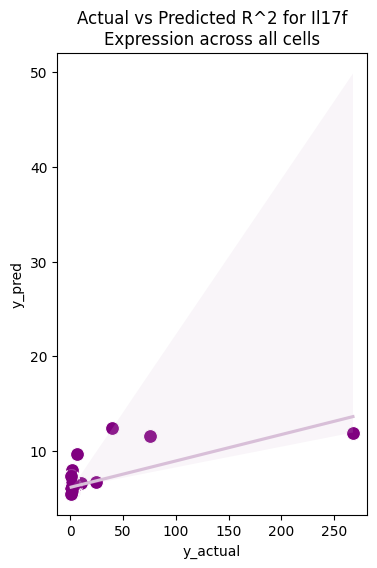

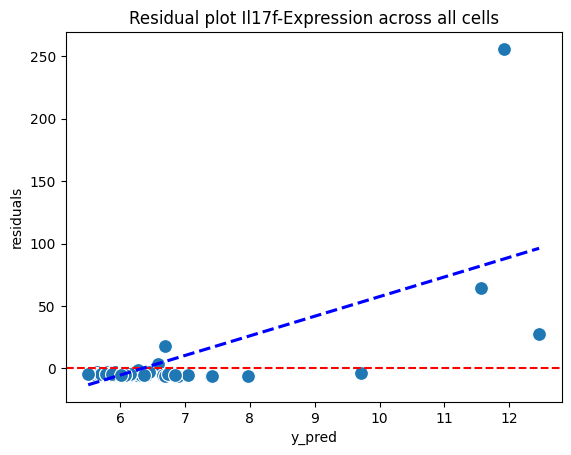

Il17f:CV=-3.792, peaks=30, best_alpha=10000


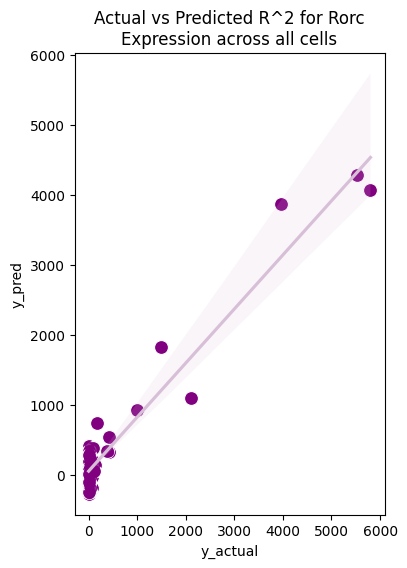

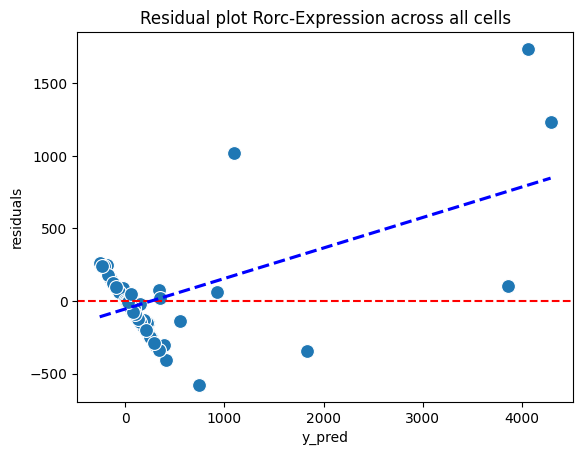

Rorc:CV=0.693, peaks=55, best_alpha=100


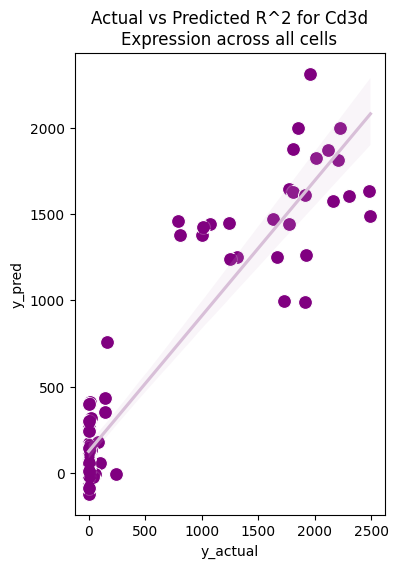

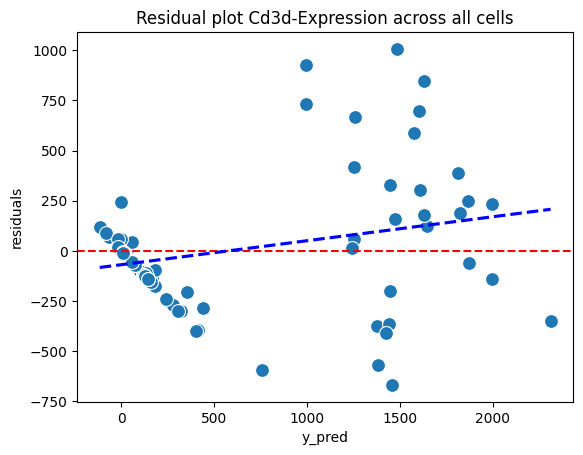

Cd3d:CV=0.750, peaks=72, best_alpha=100


In [9]:
for gen_name in ["Il17f", "Rorc","Cd3d"]: #more genes: "Sox13","Gzma", "Eomes", "Actb"
    _, cv, n,_, best_alpha,_,_,_ = r2_gen(gen_name, plot_residues=True, plot=True) #variabeln brauche ich hier für nicht
    print(f"{gen_name}:CV={cv:.3f}, peaks={n}, best_alpha={best_alpha}") #Anzahl der peaks über Zellen hinweg

<div class="alert alert-block alert-info">
A Ridge Regression model was built to predict gene expression through ATACseq peaks. <br>

A stable fit with high explained varianc is demonstrated when the model is tested on Cd3d due to its robust expression across cell types. Moderate performance is demonstrated by **Rorc**. Only a few peaks with higher variance are relied upon, meaning the model's predictive power is heavily concentrated on those specific regions. <br> In contrast, applying the model to **Il17f** results in high uncertainty because fewer peaks are strongly associated with the gene and its variance is low, which heavily promotes overfitting. 

Thus the model can only be used to comparatively evaluate *Il17f* rather than to make precise predictions in further analysis.
</div>

### Function of the regression model (R^2): lineage-specific γδ T-cells

**Function R^2_gen**

1. A matrix is created: X = peaks, Y = gene expression
2. Ridge Regression is run to select the best alpha
3. Cross Validation with best alpha
4. Predicted values are plotted against actual values
5. A residual plot is created

In [10]:
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold

annotation_cols = ["ImmGenATAC1219.peakID", "chrom", "Summit",
                   "mm10.60way.phastCons_scores", "_-log10_bestPvalue",
                   "Included.in.systematic.analysis", "TSS", "genes.within.100Kb"]


def r2_gen_gd(gen_name_gd, plot=True, plot_residues=True):   # top_k weg
    # RNA
    RNA_seq_Tgd_gen = RNA_seq_gd.loc[[gen_name_gd]]   
    y = RNA_seq_Tgd_gen.T

    # ATAC Datensatz Filtern, sodass nur peaks gewählt werden die mit Gen assoziert sind, also within 100kb
    ATAC_seq_gen = ATAC_seq_gd[ATAC_seq_gd["genes.within.100Kb"].fillna("").str.contains(rf"\b{gen_name_gd}\b")]

    peak_ids = ATAC_seq_gen["ImmGenATAC1219.peakID"].values  # ← vor .T
    X = ATAC_seq_gen.drop(annotation_cols, axis=1, errors="ignore").T #ATAC datenstz transformieren: Spalten = Peaks

    # gemeinsame Zellen angleichen
    cells = X.index.intersection(y.index)
    X = X.loc[cells]
    y = y.loc[cells]
    
    X_scaled = StandardScaler().fit_transform(X)

    ridge = RidgeCV(alphas=[10, 100, 1000, 10000, 100000], cv=KFold(5, shuffle=True, random_state=42))
    ridge.fit(X_scaled, y)

    r2 = ridge.score(X_scaled, y)
    best_alpha = ridge.alpha_
    
    # CV mit bestem alpha
    cv = cross_val_score(
        Ridge(alpha=best_alpha),
        X_scaled, y,
        cv=KFold(5, shuffle=True, random_state=0),
        scoring="r2"
    ).mean()

    y_actual = np.ravel(y.values)
    y_pred = ridge.predict(X_scaled)

    if plot:
        Reg_vis = pd.DataFrame({"y_actual": y_actual, "y_pred": y_pred})
        sns.scatterplot(data=Reg_vis, x="y_actual", y="y_pred", s=100)
        sns.regplot(data=Reg_vis, x="y_actual", y="y_pred", scatter=False,
                    line_kws={"color": "red"})
        plt.title(f"Actual vs Predicted R^2 for {gen_name_gd}-Expression across Tgd cells")
        plt.show()

    if plot_residues:
        residuals = y_actual - y_pred
        Reg_vis = pd.DataFrame({"residuals": residuals, "y_pred": y_pred})
        sns.scatterplot(data=Reg_vis, x="y_pred", y="residuals", s=100)
        plt.axhline(0, color="red", linestyle="--")
        sns.regplot(data=Reg_vis, x="y_pred", y="residuals", ci=None,
                    scatter=False, line_kws={"color": "blue", "linestyle": "--"})
        plt.title(f"Residual plot {gen_name_gd}-Expression across Tgd cells")
        plt.show()
    
    return r2, cv, X.shape[1], ridge, best_alpha, peak_ids

#### Test Function: R²_gen_gd </h3> 
Genes tested:  
* *Rorc*: one of the genes with the highest Gini coefficient in γδ T-cells
* *Il17f*: gene active in IL17-producing cells  
* *Cd3d*: highly active T-cell marker with high expression variability across cell types<br> 
<br>Visualization with plots of predicted values and residual plots 

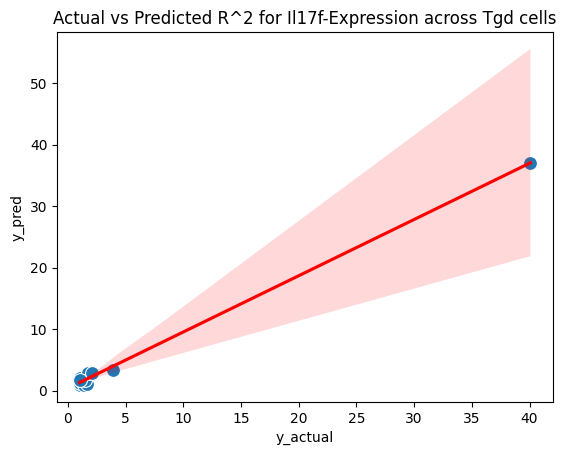

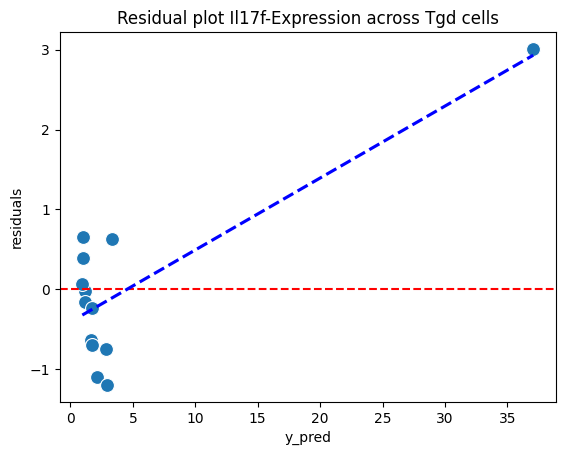

Il17f: CV=-25.579, peaks=30, best_alpha=10


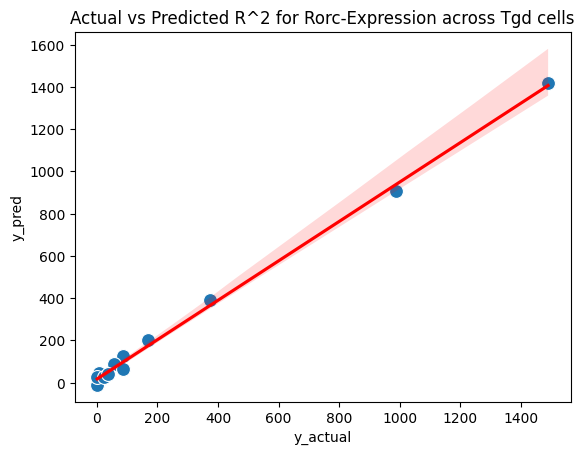

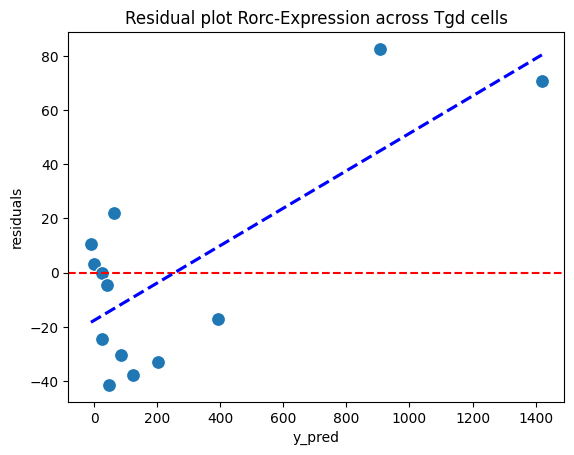

Rorc: CV=-3908.351, peaks=55, best_alpha=10


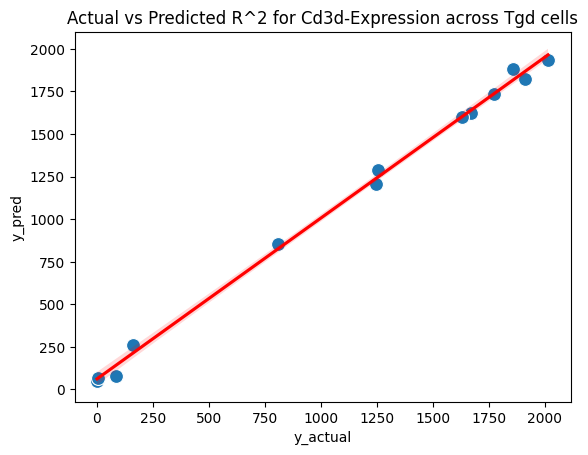

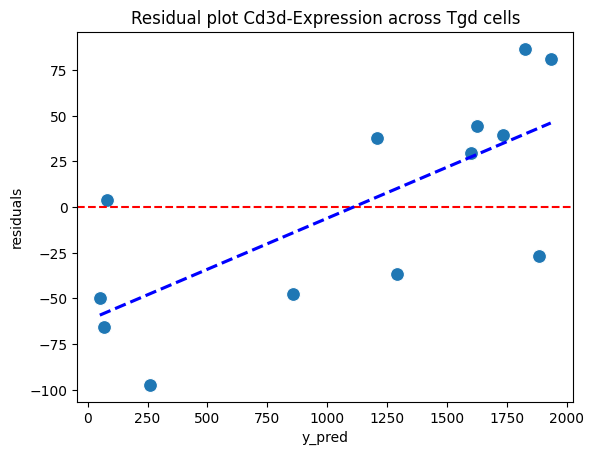

Cd3d: CV=-4.467, peaks=72, best_alpha=10


In [11]:
for gen_name_gd in ["Il17f", "Rorc", "Cd3d"]: #"Gzma", "Eomes", "Actb" 
    _, cv, n,_,best_alpha,_= r2_gen_gd(gen_name_gd)
    print(f"{gen_name_gd}: CV={cv:.3f}, peaks={n}, best_alpha={best_alpha}") #Anzahl der peaks über Zellen hinweg

<div class="alert alert-block alert-info">
A second Ridge model was trained specifically on γδ T-cell development. This model shows negative cross-validation scores, meaning it performs worse at predicting gene expression than simply guessing the mean of y for every cell type. This is because the model is trained on only 13 γδ T-cell types, making it highly prone to overfitting and it cannot generalize reliably within this limited cell lineage.
</div>



## How do regression coefficients change when the model is fit on your lineage alone versus all cell types?


<h3>Analysis of Ridge Regression Coefficients</h3>

$$\hat{Y}_i = b_0 + b_1 X_{i1} + b_2 X_{i2} + \dots + b_n X_{in}$$

In the model, the weight of a single peak is represented by each coefficient. ($b_1, b_2, \dots, b_n$). To evaluate how gene expression is influenced by peak accessibility across the two models, the following approach was used:

1. For each gene, the exact same set of peaks will be used (common peak set) for both the all-cells and the Tγδ-specific models.
2. For every individual peak, the sign (positive or negative) of its coefficient between the all-cells model and the Tgd model is compared.
3. The total number and the proportion of peaks that change their sign between the two approaches are calculated to assess model stability and lineage-specific differences.

<h3> Comparison of coefficient values across tested genes

In [12]:
genes = "Il17f", "Arpp21",  "Eomes", "Gzma", "Kcnk1", "Rorc", "Sox13", "Actb", "Hprt", "Rplp0" ,"Cd3d"
results = []
coef_tables = {}  # speichert coef_table pro Gen

for gen in genes:
    r2_all,cv_all, n_all,reg_all,best_alpha_all,peaks_all,_,_ = r2_gen(gen, plot=False, plot_residues = False) #increasing rigid penalty to reduce overfitting
    r2_gd, _, n_gd, reg_gd, best_alpha_gd, peaks_gd = r2_gen_gd(gen, plot=False, plot_residues=False)
    
    #nur gemeinsame Peaks (verhindert Längen-Mismatch)
    coef_table = pd.DataFrame(
        {"all_cells": reg_all.coef_.ravel(),
         "Tgd":       reg_gd.coef_.ravel()},
        index=peaks_all                           # ImmGenATAC1219.peakID als Index
    )

    coef_table["gene"] = gen  # Gen-Spalte hinzufügen
    coef_tables[gen] = coef_table  # speichern

    sign_changes = (np.sign(coef_table["all_cells"]) != np.sign(coef_table["Tgd"])).sum()
    
    results.append({                            #append: erweitert Liste
        "gene": gen,
        "n_peaks": len(coef_table),
        "sign_changes": sign_changes,
        "percent_sign_changes": 100 * sign_changes / len(coef_table)
        })



coef_genes_compare = pd.DataFrame(results)
coef_genes_compare

,gene,n_peaks,sign_changes,percent_sign_changes
0,Il17f,30,11,36.666667
1,Arpp21,56,15,26.785714
2,Eomes,62,25,40.322581
3,Gzma,68,27,39.705882
4,Kcnk1,33,8,24.242424
5,Rorc,55,18,32.727273
6,Sox13,50,10,20.000000
7,Actb,85,28,32.941176
8,Hprt,36,7,19.444444
9,Rplp0,78,27,34.615385


#### Scatterplot
for selected genes: *Rorc*, *Il17f*
<br><br>

The coefficients are visualized using a scatter plot:

* **X-axis:** Regression Coefficient in the all-cells model
* **Y-axis:** Regression Coefficient in the Tgd model

In [13]:
def scattplot_coef(gen): 
    coef_table = coef_tables[gen].copy()
    
    coef_table["sign_changes"] = (np.sign(coef_table["all_cells"]) != np.sign(coef_table["Tgd"]))

    plt.figure(figsize=(6, 6))
    sns.scatterplot(
        data=coef_table,
        x="all_cells",
        y="Tgd",
        hue="sign_changes",
        palette={False: "steelblue", True: "tomato"},
        alpha=0.8
    )
    
    plt.axhline(0, color="grey", linestyle="--", linewidth=0.8)
    plt.axvline(0, color="grey", linestyle="--", linewidth=0.8)
    plt.plot(
        [coef_table["all_cells"].min(), coef_table["all_cells"].max()], #diagonale die perfekt 45 Grad Winkel verläuft
        [coef_table["all_cells"].min(), coef_table["all_cells"].max()],
        color="black", linestyle=":", linewidth=0.8,
        label="y = x"
    )

    plt.xlabel("Coefficient (all cells)")
    plt.ylabel("Coefficient (Tgd)")
    plt.title(f"{gen}: Regression coefficients\nall cells vs. Tgd")
    plt.legend(title="Sign change", loc="best")
    plt.tight_layout()
    plt.show()

*Actb*: Houskeeping gen

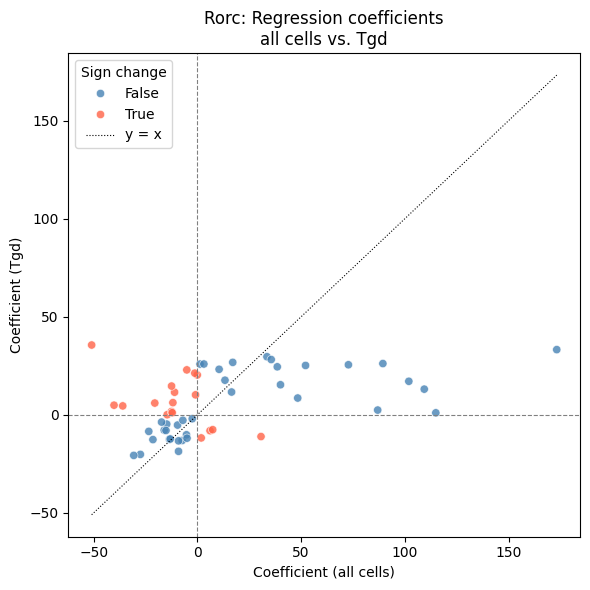

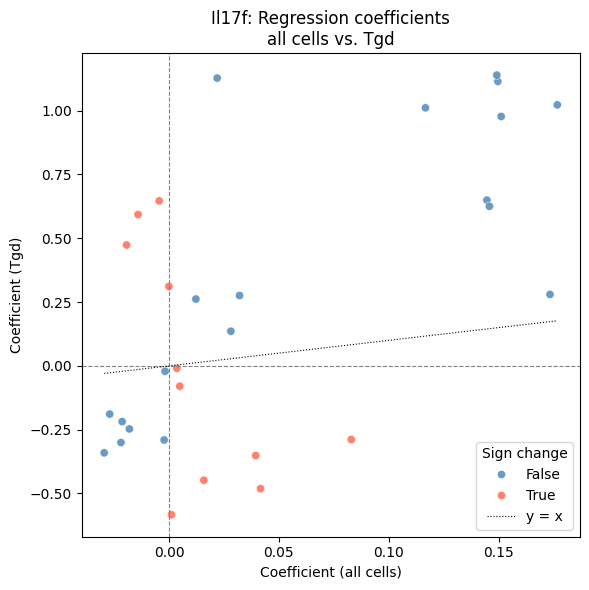

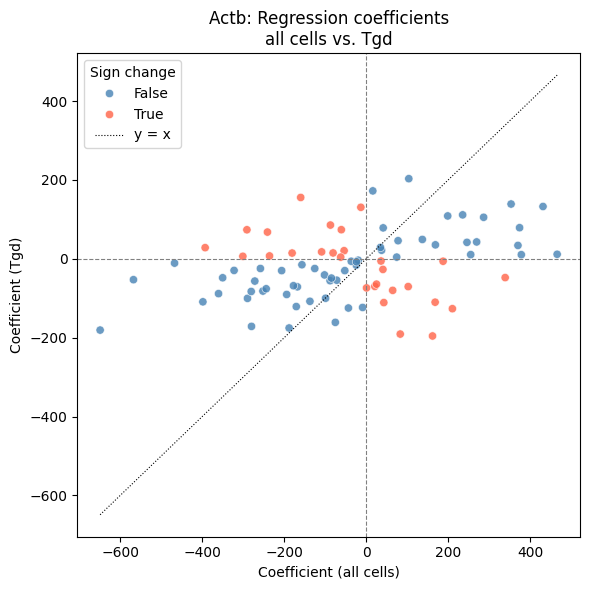

In [14]:
for gen in ["Rorc", "Il17f", "Actb"]: # "Gzma", "Eomes","Sox13","Cd3d",
    scattplot_coef(gen)

* *Actb*: points are symmetrical distributed around diagonal line
* *Rorc*: Similar to Actb, but peaks in the positive quadrant are weighted weaker in the Tγδ model
* *Il17f*: Model shows no clear pattern


## Which CREs drive expression of your lineage-specific genes?

Top CREs for specific genes are determined by finding the highest absolute difference between the all-cells and Tγδ coefficients.

In [15]:
high_gini_Tgd = ["Il17f", "Cd3d", "Rorc"]# "Gzma", "Kcnk1", "Rorc", "Sox13", "Il17f", "Cd3d"

for gen in high_gini_Tgd:
    # filtern absolut
    filtered = coef_tables[gen][abs(coef_tables[gen]["Tgd"]) > abs(coef_tables[gen]["all_cells"])].copy()
    
    #spalte für den absoluten Abstand
    filtered["abs_distance"] = filtered["Tgd"].abs()
    
    #Nach absolutem Abstand sortieren und Spalte dann löschen
    top_drive = filtered.sort_values("abs_distance", ascending=False).drop(columns=["abs_distance"]) 

    print(f"\n{gen} – Top Tγδ-driving CREs:")
    print(top_drive.head(10))


Il17f – Top Tγδ-driving CREs:
                          all_cells       Tgd   gene
ImmGenATAC1219.peak_2090   0.149211  1.139377  Il17f
ImmGenATAC1219.peak_2086   0.021907  1.127834  Il17f
ImmGenATAC1219.peak_2075   0.149677  1.114854  Il17f
ImmGenATAC1219.peak_2095   0.176759  1.022718  Il17f
ImmGenATAC1219.peak_2089   0.116722  1.011223  Il17f
ImmGenATAC1219.peak_2081   0.151196  0.977415  Il17f
ImmGenATAC1219.peak_2083   0.144711  0.649584  Il17f
ImmGenATAC1219.peak_2109  -0.004486  0.646648  Il17f
ImmGenATAC1219.peak_2085   0.145833  0.625246  Il17f
ImmGenATAC1219.peak_2116  -0.014109  0.593164  Il17f

Cd3d – Top Tγδ-driving CREs:
                            all_cells        Tgd  gene
ImmGenATAC1219.peak_482211  20.444442  47.107933  Cd3d
ImmGenATAC1219.peak_482197  26.288307  45.671452  Cd3d
ImmGenATAC1219.peak_482235 -14.626588 -39.689922  Cd3d
ImmGenATAC1219.peak_482172 -24.734433 -38.852603  Cd3d
ImmGenATAC1219.peak_482176   7.168351 -38.841240  Cd3d
ImmGenATAC1219.peak_482202

**Visualization** 
The top 5 Tγδ peaks per gene are used to analyze the association between the chromatin accessibility of each peak and the gene expression across the γδ lineage. 

                          all_cells       Tgd   gene
ImmGenATAC1219.peak_2090   0.149211  1.139377  Il17f
ImmGenATAC1219.peak_2086   0.021907  1.127834  Il17f
ImmGenATAC1219.peak_2075   0.149677  1.114854  Il17f
ImmGenATAC1219.peak_2095   0.176759  1.022718  Il17f
ImmGenATAC1219.peak_2089   0.116722  1.011223  Il17f
                            all_cells        Tgd  gene
ImmGenATAC1219.peak_312422  17.029479  26.728689  Rorc
ImmGenATAC1219.peak_312426   3.125627  25.887710  Rorc
ImmGenATAC1219.peak_312420   1.265211  25.848735  Rorc
ImmGenATAC1219.peak_312447  10.458059  23.193540  Rorc
ImmGenATAC1219.peak_312421  -5.105702  22.888483  Rorc


/var/folders/cc/3r9cpp9s7c9_s16wz91nlkn40000gn/T/ipykernel_9210/1679891205.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


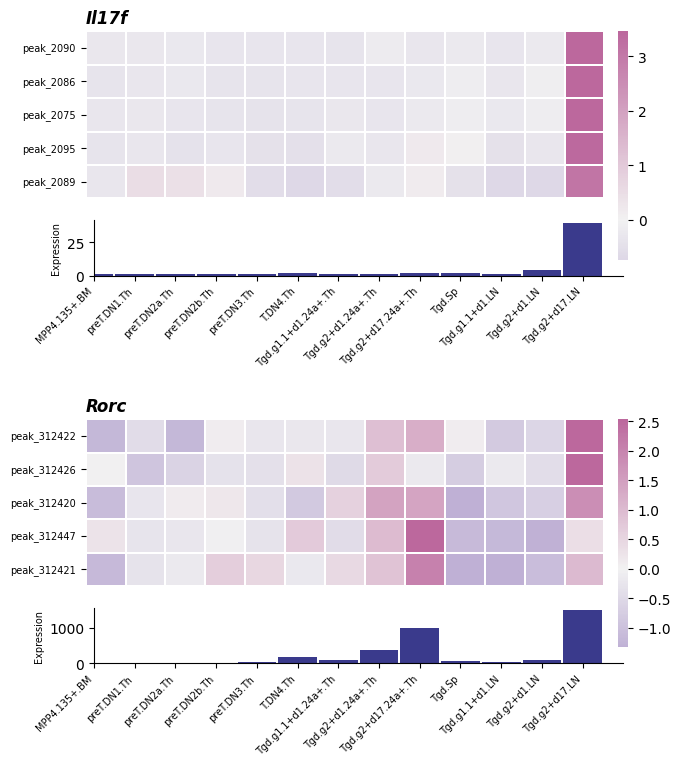

In [16]:
from sklearn.preprocessing import StandardScaler

Tgd_cells = [
        "MPP4.135+.BM",
        "preT.DN1.Th",
        "preT.DN2a.Th",
        "preT.DN2b.Th",
        "preT.DN3.Th",
        "T.DN4.Th",
        "Tgd.g1.1+d1.24a+.Th",
        "Tgd.g2+d1.24a+.Th",
        "Tgd.g2+d17.24a+.Th",
        "Tgd.Sp",
        "Tgd.g1.1+d1.LN",
        "Tgd.g2+d1.LN",
        "Tgd.g2+d17.LN"
    ]

cmap = sns.diverging_palette(
        280,
        330,
        s=45,
        l=55,
        center="light",
        as_cmap=True
    )

genes = ["Il17f", "Rorc"]#, "Il17f", "Cd3d", "Rorc"

fig = plt.figure(figsize=(7, 4 * len(genes)))
outer = fig.add_gridspec(
        len(genes), 2,
        width_ratios=[50, 1],
        wspace=0.05,
        hspace=0.7
    )

for i, gen in enumerate(genes):
        # Inneres gridspec: Heatmap oben (3 Teile), Barplot unten (1 Teil)
        inner = outer[i, 0].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.05)

        ax_heat = fig.add_subplot(inner[0])
        ax_bar = fig.add_subplot(inner[1], sharex=ax_heat)
        cax = fig.add_subplot(outer[i, 1])

        filtered_coef = coef_tables[gen][abs(coef_tables[gen]["Tgd"]) > abs(coef_tables[gen]["all_cells"])].copy()
        top5 = filtered_coef.sort_values("Tgd", ascending=False).head(5)
        print(top5)

        rows = []
        for peak_id in top5.index:
            row = ATAC_seq_gd[ATAC_seq_gd["ImmGenATAC1219.peakID"] == peak_id]
            if not row.empty:
                vals = row[Tgd_cells].iloc[0]
                sauberer_name = peak_id.replace("ImmGenATAC1219.", "") #ImmgenATAC1219 in y-Achse Beschriftung rausgenommen
                vals.name = sauberer_name
                rows.append(vals)

        heat_df = pd.DataFrame(rows)
        heat_df_z = StandardScaler().fit_transform(heat_df.T) # skaliert über Tgd-Zelltypen je Peak (dafür transformieren) --> damit alle peaks auf derselben skala liegen (z=2: Standartabweichung 2 besonders offen für den peak)
        heat_df_z = pd.DataFrame(heat_df_z.T, index=heat_df.index, columns=heat_df.columns)

        sns.heatmap(
            heat_df_z,
            ax=ax_heat,
            cmap=cmap,
            center=0,
            robust=True,
            linewidths=0.3,
            xticklabels=False,
            yticklabels=True,
            cbar=True,
            cbar_ax=cax
        )

        ax_heat.set_title(gen, fontstyle="italic", fontweight="bold", loc="left")

        # Heatmap-Zellnamen kleiner
        ax_heat.tick_params(axis='x', labelbottom=False, bottom=False)   # z.B. 7 oder 8
        ax_heat.tick_params(axis='y', labelsize=7)   # z.B. 7 oder 8

        # Barplot RNA: RNA‑Expression des Gens in den Tγδ‑Zelltypen
        
        if gen in RNA_seq_gd.index:            
            rna_row = RNA_seq_gd.loc[[gen]]
            rna_vals = rna_row[Tgd_cells].iloc[0]

            ax_bar.bar(
                np.arange(len(Tgd_cells)),
                rna_vals.values,
                width=0.95,
                color="#3a3a8c"
            )
            ax_bar.set_xticks(np.arange(len(Tgd_cells)))
            ax_bar.set_xticklabels(Tgd_cells, rotation=45, ha="right", fontsize=7)
            ax_bar.set_ylabel("Expression", fontsize=7)
            ax_bar.spines[["top", "right"]].set_visible(False)

        ax_heat.set_xlim(0, len(Tgd_cells))
        ax_bar.set_xlim(0, len(Tgd_cells))

        heat_pos = ax_heat.get_position()
        bar_pos = ax_bar.get_position()

        # Barplot nach rechts, nach unten und etwas länger
        ax_bar.set_position([
            heat_pos.x0 + 0.012,      # nach rechts
            bar_pos.y0 - 0.02,        # nach unten
            heat_pos.width + 0.015,   # etwas länger/breiter
            bar_pos.height
        ])
#plt.savefig(f"plots_for_poster/top_peaks_ATAC_RNA_{genes}", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

*Il17f*
* Accessibility and gene expression of the top peaks chosen with the regression model are almost entirely restricted to Tgd.g2+d17.LN.

*Rorc*
* Broad regulatory pattern, not completly restricted to a single early subset
* Chromatin accessibility and gene expression rise after the precursor T-cell stages
* High in chromatin accessibilty and expression in the mature Tgd.g2+d17.24a+.Th and Tgd.g2+d17.LN populations

<div class="alert alert-block alert-info">
Considering the limitations of the models, specifically the lineage-specific one, a correlation analysis (see 09_Correlation_ATAC_signal_to_RNA_expression) is more trustworthy.
</div>

# Repressive vs. Active CREs

### Activating vs. repressing CREs based on sign of reg. coef.

First, CREs within 100 kb of each gene were identified and saved as dictionary.

In [9]:
def build_gene_peak_dict(ATAC_seq):

    gene_to_peaks = {}
    ATAC_filtered = ATAC_seq[ATAC_seq["genes.within.100Kb"].notna()]

    for index, row in ATAC_filtered.iterrows():
        
        peak_ID = row["ImmGenATAC1219.peakID"]

        for gene in str(row["genes.within.100Kb"]).split(","):
            
            gene = gene.strip()

            if gene not in gene_to_peaks:
                gene_to_peaks[gene] = []
            
            gene_to_peaks[gene].append(peak_ID)

    return gene_to_peaks

gene_peak_dictionary = build_gene_peak_dict(ATACseq_reg)

In [10]:
#saving the dictionary

gene_peak_df = pd.DataFrame([(gene, peak)
     for gene, peaks in gene_peak_dictionary.items()
     for peak in peaks],columns=["gene", "peakID"])

gene_peak_df.to_csv('data/gene_peak_dictionary.csv', index=False) 

Next, a function is build that fits a ridge regression model with the gene-specific CREs chosen in the dictionary and then extracts the coeffiecient for each CRE.

In [26]:
#extra Packages

from sklearn.linear_model import Ridge, RidgeCV #choose best alpha w/ ridgeCV
from sklearn.preprocessing import StandardScaler #mean=0 sd=1
from sklearn.metrics import r2_score 
from sklearn.model_selection import cross_val_score, KFold

from sklearn.pipeline import make_pipeline 

In [28]:
#r2_gen_TSS - ridge function w/ Promotor

ATACseq_reg_TSS = ATAC_seq.copy()

def r2_gen_TSS(gen_name):

    #Y_RNA
    RNA_seq_Gene = RNA_seq.loc[[gen_name]]
    y = RNA_seq_Gene.drop("Unnamed: 0", axis=1, errors="ignore").T

    #X_ATAC
    peak_ids = gene_peak_dictionary.get(gen_name, [])
    ATAC_seq_Gene = ATACseq_reg_TSS[ATACseq_reg_TSS["ImmGenATAC1219.peakID"].isin(peak_ids)]

    X = ATAC_seq_Gene.drop(meta_cols, axis=1, errors="ignore").T
    
    #Index angleichen
    common_cells = X.index.intersection(y.index)
    X = X.loc[common_cells]
    y = y.loc[common_cells]

    #Standardscale and choosing best alpha
    X_scaled = StandardScaler().fit_transform(X)
    ridge = RidgeCV(alphas=[10, 100, 1000, 10000, 100000], cv=KFold(5, shuffle=True, random_state=0))
    ridge.fit(X_scaled, y)

    r2 = ridge.score(X_scaled, y)
    best_alpha = ridge.alpha_

    # CV mit bestem alpha
    cv = cross_val_score(
        make_pipeline(StandardScaler(), Ridge(alpha=best_alpha)),
        X, y,
        cv=KFold(5, shuffle=True, random_state=0),
        scoring="r2"
    ).mean()
        
    return  r2, cv, ridge

In [29]:
#Coefficient Dataframe

def coef_gen(gen_name):
    r2, cv, ridge = r2_gen_TSS(gen_name)

    peak_ids = gene_peak_dictionary.get(gen_name, [])
    coef_df = pd.DataFrame({"peakID": peak_ids, "coefficient": ridge.coef_})

    #eine Spalte soll direkt Vorzeichen interpretieren
    coef_df["sign"] = coef_df["coefficient"].apply(lambda x: "+" if x > 0 else "-")

    # Effektstärke
    coef_df["abs_coefficient"] = coef_df["coefficient"].abs().round(1)

    # zuerst repressing/activating, dann nach Stärke
    coef_df = coef_df.sort_values(by=["abs_coefficient"], ascending=[False])

    return coef_df, r2, cv, peak_ids

coef_Gzma, r2, cv, peak_ids = coef_gen("Gzma")
coef_Gzma

,peakID,coefficient,sign,abs_coefficient
22,ImmGenATAC1219.peak_142098,718.268051,+,718.3
17,ImmGenATAC1219.peak_142093,487.313700,+,487.3
18,ImmGenATAC1219.peak_142094,-419.764119,-,419.8
48,ImmGenATAC1219.peak_142129,410.201623,+,410.2
36,ImmGenATAC1219.peak_142114,402.325683,+,402.3
...,...,...,...,...
3,ImmGenATAC1219.peak_142071,9.154861,+,9.2
11,ImmGenATAC1219.peak_142082,-7.146110,-,7.1
57,ImmGenATAC1219.peak_142143,6.824026,+,6.8
58,ImmGenATAC1219.peak_142144,-3.667355,-,3.7


Functions were applied to determine regression coefficients for all CREs associated with each gene. A dataframe containing only repressing CREs was generated (based on how much influence negative coefficients had in relation to all coefficients).

In [ ]:
#function that checks which Genes are regulated primarely by repressive CREs


def find_repressive_genes(RNAseq, rep_threshold = 50, topk_threshold = 10):

    results = []

    genes = RNAseq["Unnamed: 0"].unique()

    for gene in genes:
        try:
            coef_df, r2, cv = coef_gen(gene)

            #Repressionsanteil
            total_effect = coef_df["abs_coefficient"].sum()

            if total_effect == 0:
                continue
            
            repression_percent = (coef_df.loc[coef_df["coefficient"] < 0,"abs_coefficient"].sum()
                                  /total_effect) * 100
            
            #Ist unter den Top-k mindestens ein Repressor?
            topk_has_repressor = (coef_df.sort_values("abs_coefficient", ascending=False).head(topk_threshold)["coefficient"] < 0).any()

            #Criterions erfüllt?
            if (repression_percent >= rep_threshold and topk_has_repressor):
                
                strongest_repressor = (coef_df[coef_df["coefficient"] < 0].sort_values("abs_coefficient", ascending=False).iloc[0])

                strongest_activator = (coef_df[coef_df["coefficient"] > 0].sort_values("abs_coefficient", ascending=False).iloc[0])

                results.append({
                    "gene": gene,
                    "repression_percent": round(repression_percent,1),

                    "strongest_repressor_peakID": strongest_repressor["peakID"],
                    "strongest_repressor_coef": strongest_repressor["coefficient"],

                    "strongest_activator_peakID": strongest_activator["peakID"],
                    "strongest_activator_coef": strongest_activator["coefficient"],

                    "r2": round(r2, 2),
                    "cv": round(cv, 2),

                    "cv_category":
                        "Sehr Gut" if cv > 0.85 else
                        "Okay" if cv > 0.59 else
                        "wenigstens im positiven" if cv > 0 else
                        "negativ :(",
                })
                        
        except Exception:
            continue
        
    return pd.DataFrame(results)


givamialista = find_repressive_genes(RNA_seq, rep_threshold = 50, topk_threshold = 10)
givamialista.to_csv("data/repressive_regulated_genes.csv",index=False)

A dictionary mapping each gene to its peaks was created to make further functions analysing peak_coef_pairs more efficient.

In [ ]:
#dictionary with all genes listed and their respective peaks within 100kb
gene_peak_dictionary


#dictionary with all genes listed and the abs_coef of all their peaks

gene_coef_dictionary = {}

for gen_name in gene_peak_dictionary.keys():
    try:
        coef_df, r2, cv, peak_ids = coef_gen(gen_name)
        
        peak_coef_dict = dict(zip(coef_df["peakID"],coef_df["coefficient"]))

        gene_coef_dictionary[gen_name] = {
                "cv": cv,
                "r2": r2,
                "coefs": peak_coef_dict}
    
    except Exception as e:
        gene_coef_dictionary[gen_name] = {
                "cv": None,
                "r2": None,
                "coefs": {},
                "error": str(e)
            }

gene_coef_df = pd.DataFrame.from_dict(
    gene_coef_dictionary,
    orient="index"
).reset_index()

gene_coef_df = gene_coef_df.rename(
    columns={"index": "gene"}
)

gene_coef_df.to_csv("data/gene_coef_dictionary.csv", index=False)

### How many genes are primarily regulated by repressive CREs?

In [ ]:
#extracting coef_dictionary

gene_coef_dictionary_path = Path('data') / 'gene_coef_dictionary.csv'
gene_coef_dictionary = pd.read_csv(gene_coef_dictionary_path)
gene_coef_dictionary = gene_coef_dictionary.dropna(subset=["cv"])

genes_OkayCV = gene_coef_dictionary[gene_coef_dictionary["cv"] >= 0.35]


#dataframe (gene|rep.%|rep. or act|strongest rep.|strongest act.)

genes_by_rep_perc = []

for gene in genes_OkayCV["gene"]:
    
    row = genes_OkayCV.loc[genes_OkayCV["gene"] == gene].iloc[0]
    coef_dict = literal_eval(row["coefs"])

    coef_theframe = pd.DataFrame({
    "peak_id": coef_dict.keys(),
    "coefficient": coef_dict.values()})

    coef_theframe["abs_coefficient"] = coef_theframe["coefficient"].abs()

    
    repression_percent = (coef_theframe.loc[coef_theframe["coefficient"] < 0,"abs_coefficient"].sum() /coef_theframe["abs_coefficient"].sum()) * 100

    label = "repressive" if repression_percent > 50 else "active"

    genes_by_rep_perc.append({
        "gene": gene,
        "rep_perc": repression_percent,
        "rep_or_act": label,
        "min_coef": coef_theframe["coefficient"].min(),
        "max_coef": coef_theframe["coefficient"].max()
    })

genes_by_rep_perc = pd.DataFrame(genes_by_rep_perc)
genes_by_rep_perc    



The repression percentage was calculated for every gene and visualized as a histogram.

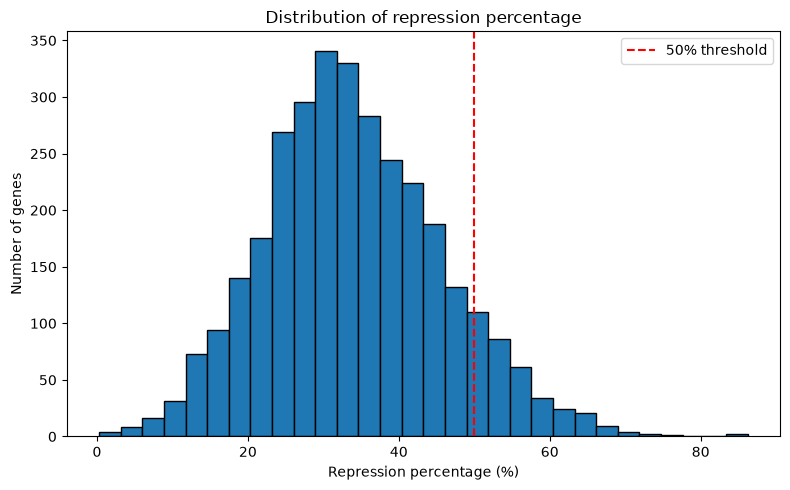

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(genes_by_rep_perc["rep_perc"], bins=30, edgecolor="black")

plt.axvline(50, color="red", linestyle="--", label="50% threshold")

plt.xlabel("Repression percentage (%)")
plt.ylabel("Number of genes")
plt.title("Distribution of repression percentage")
plt.legend()

plt.tight_layout()
plt.show()

The distribution is centered below the 50% threshold, indicating that most genes are predominantly regulated by activating rather than repressing CREs.

### Where are repressing CREs located relative to activating CREs?

Distance to TSS of all CREs were determined, afterwards the distribution between activating and repressive CREs were compared.

In [ ]:
#list all peaks
rows = []

for _, row in genes_OkayCV.iterrows():

    gene = row["gene"]
    coef_dict = eval(row["coefs"])

    for peak_id, coef in coef_dict.items():

        rows.append({
            "gene": gene,
            "peakID": peak_id,
            "coef": coef,
            "sign": "activating" if coef > 0 else "repressing"
        })

peak_gene_pairs = pd.DataFrame(rows)

In [ ]:
#find summit of every peak

peak_gene_pairs = peak_gene_pairs.merge(
    ATAC_data[["ImmGenATAC1219.peakID", "Summit"]],
    left_on="peakID",
    right_on="ImmGenATAC1219.peakID",
    how="left"
).drop(columns="ImmGenATAC1219.peakID")

display(peak_gene_pairs)

,gene,peakID,coef,sign,Summit
0,Sgk3,ImmGenATAC1219.peak_605,17.242355,activating,9813129
1,Sgk3,ImmGenATAC1219.peak_660,-16.414478,repressing,9944186
2,Sgk3,ImmGenATAC1219.peak_604,14.587984,activating,9810817
3,Sgk3,ImmGenATAC1219.peak_582,14.341511,activating,9769742
4,Sgk3,ImmGenATAC1219.peak_601,13.692282,activating,9806129
...,...,...,...,...,...
215942,Tmlhe,ImmGenATAC1219.peak_512480,-0.921283,repressing,161388
215943,Tmlhe,ImmGenATAC1219.peak_512486,0.351447,activating,259184
215944,Tmlhe,ImmGenATAC1219.peak_512474,0.333160,activating,128427
215945,Tmlhe,ImmGenATAC1219.peak_512475,-0.186884,repressing,139034


In [ ]:
#calculate TSS

gene_annotations["TSS"] = gene_annotations.apply(
    lambda row: row["txStart"] if row["strand"] == "+" else row["txEnd"],
    axis=1
)

#add calculate to df
peak_gene_pairs = peak_gene_pairs.merge(
    gene_annotations[["gene_name", "TSS"]].drop_duplicates("gene_name"),
    left_on="gene",
    right_on="gene_name",
    how="left"
).drop(columns="gene_name")

peak_gene_pairs["distance_to_TSS"] = peak_gene_pairs["Summit"] - peak_gene_pairs["TSS"]

display(peak_gene_pairs)

,gene,peakID,coef,sign,Summit,TSS,distance_to_TSS
0,Sgk3,ImmGenATAC1219.peak_605,17.242355,activating,9813129,9798129.0,15000.0
1,Sgk3,ImmGenATAC1219.peak_660,-16.414478,repressing,9944186,9798129.0,146057.0
2,Sgk3,ImmGenATAC1219.peak_604,14.587984,activating,9810817,9798129.0,12688.0
3,Sgk3,ImmGenATAC1219.peak_582,14.341511,activating,9769742,9798129.0,-28387.0
4,Sgk3,ImmGenATAC1219.peak_601,13.692282,activating,9806129,9798129.0,8000.0
...,...,...,...,...,...,...,...
215942,Tmlhe,ImmGenATAC1219.peak_512480,-0.921283,repressing,161388,159644.0,1744.0
215943,Tmlhe,ImmGenATAC1219.peak_512486,0.351447,activating,259184,159644.0,99540.0
215944,Tmlhe,ImmGenATAC1219.peak_512474,0.333160,activating,128427,159644.0,-31217.0
215945,Tmlhe,ImmGenATAC1219.peak_512475,-0.186884,repressing,139034,159644.0,-20610.0


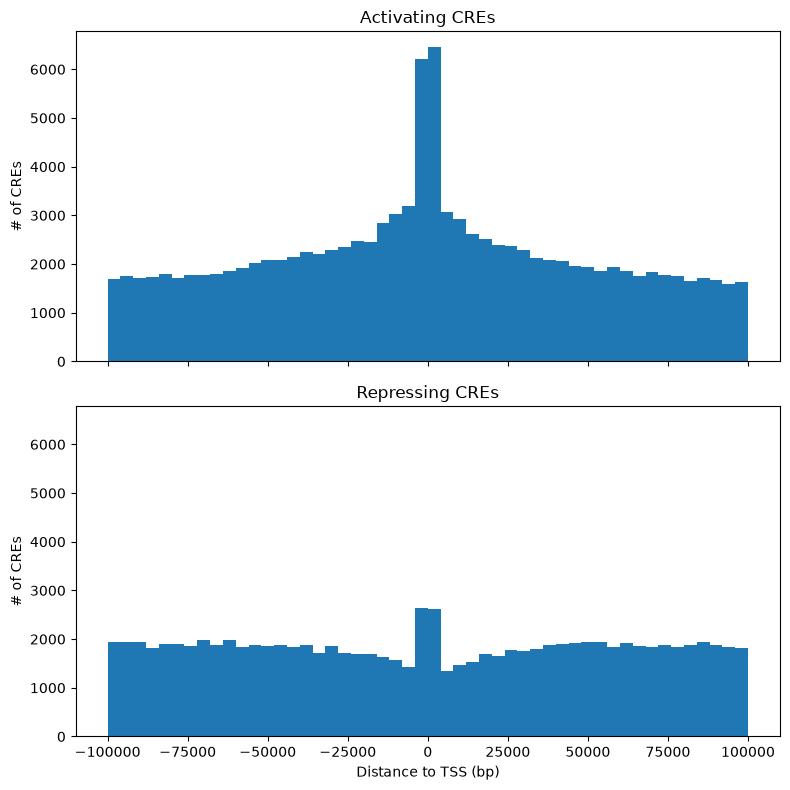

In [ ]:
plot_df = peak_gene_pairs[
    peak_gene_pairs["distance_to_TSS"].abs() <= 100000
]

plot_df = peak_gene_pairs[
    peak_gene_pairs["distance_to_TSS"].abs() <= 100000
]

fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True, sharey=True)

# Activating
axes[0].hist(
    plot_df.loc[plot_df["sign"] == "activating", "distance_to_TSS"],
    bins=50
)
axes[0].set_title("Activating CREs")
axes[0].set_ylabel("# of CREs")

# Repressing
axes[1].hist(
    plot_df.loc[plot_df["sign"] == "repressing", "distance_to_TSS"],
    bins=50
)
axes[1].set_title("Repressing CREs")
axes[1].set_xlabel("Distance to TSS (bp)")
axes[1].set_ylabel("# of CREs")

plt.tight_layout()
plt.show()

Both activating and repressing CREs are distributed across the entire 100 kb area. However, activating CREs show a more pronounced enrichment directly at the TSS, consistent with promoter activation. In contrast, repressing CREs are more evenly distributed across distal regions.